Disciplina: Data Mining e Data Graph Professor: André Luiz B. Esperidião

Aluno(a): Luca Atanazio Evangelista Matrícula: 2784239 Curso: TECNOLOGIA EM INTELIGÊNCIA ARTIFICIAL Período: 3°

# Setup e Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Matplotlib is building the font cache; this may take a moment.


## Modelos Lineares e Não Lineares

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

# Carregamento de dados

In [3]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Preparação

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelagem

In [5]:
models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Avaliação

In [6]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    # Métricas de Regressão
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    results.append({
        "Modelo": name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })

# Resultados

--- COMPARATIVO DE MODELOS (DIABETES) ---
                         Modelo  R2 Score       RMSE        MAE
0  Linear Regression (Baseline)  0.452603  53.853446  42.794095
2                 Random Forest  0.441469  54.398351  44.171236
3                      AdaBoost  0.434057  54.758130  45.127275
4                       XGBoost  0.359479  58.254398  46.726709
1                 Decision Tree  0.077603  69.907081  53.921348


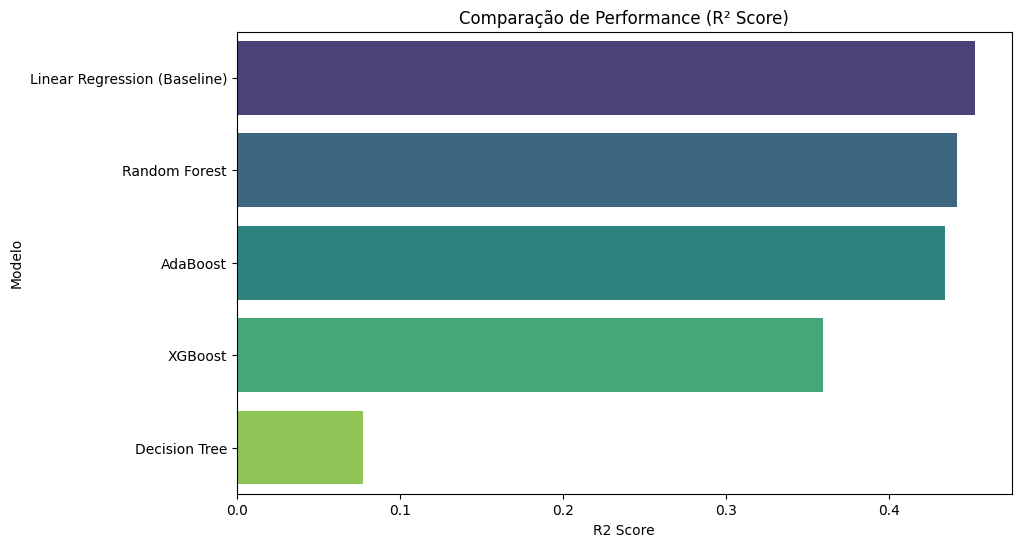

In [7]:
df_results = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("--- COMPARATIVO DE MODELOS (DIABETES) ---")
print(df_results)


plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score', y='Modelo', data=df_results, hue='Modelo', legend=False, palette='viridis')
plt.title('Comparação de Performance (R² Score)')
plt.show()





Modelo | R2 Score (Melhor ↑) | RMSE (Melhor ↓) | MAE 
--- | --- | --- | ----
Linear Regression| 0.452 | 53.85 | 42.79 
Random Forest | 0.441 | 54.39 | 44.17
AdaBoost | 0.434 | 54.75 | 45.12
XGBoost | 0.359 | 58.25 | 46.72 
Decision Tree | 0.077 | 69.90 | 53.92

## Regressão Linear apresentou o melhor $R^2$ Score
Temos esse resultado pois o dataset de diabetes possui uma dimensionalidade baixa e as relações entre biomarcadores costumam ser lineares

## Árvore de Decisão pura teve o pior desempenho
O que indica que ela tentou decorar os dados de treino e falhou ao generalizar para o teste

## Desempenho inferior do XGBoost
Indica que modelos de boosting precisam de um ajuste fino (fine-tuning) maior ou de um volume de dados superior para superar a regressão clássica neste caso específico